In [1]:
import sys
from pathlib import Path
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from tqdm.notebook import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import get_graph, list_available_datasets
from src.embeddings.graph_embeddings import get_embeddings

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Папка для сохранения моделей
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
DATASETS = ['facebook', 'arxiv', 'lastfm', 'twitch_ru']

# Параметры эмбеддингов
EMBEDDING_PARAMS = {
    'method': 'node2vec',
    'dimensions': 32,
    'walk_length': 30,
    'num_walks': 5,
    'workers': 2,
    'seed': 42
}

# Метрики для сводной таблицы
RESULTS = []

In [3]:
def prepare_link_prediction_data(G, emb_matrix):
    """
    Готовит X, y для задачи предсказания связей.
    Возвращает признаки (Hadamard product) и метки.
    """
    if G.is_directed():
        G = G.to_undirected()
    
    nodes = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    
    # Положительные примеры — все рёбра
    edges = list(G.edges())
    
    # Отрицательные — случайные пары без ребра (столько же, сколько рёбер)
    non_edges = list(nx.non_edges(G))
    np.random.seed(42)
    neg_indices = np.random.choice(len(non_edges), size=len(edges), replace=False)
    neg_edges = [non_edges[i] for i in neg_indices]
    
    def edge_features(u, v):
        emb_u = emb_matrix[node_to_idx[u]]
        emb_v = emb_matrix[node_to_idx[v]]
        return emb_u * emb_v  # Hadamard product
    
    X_pos = np.array([edge_features(u, v) for u, v in edges])
    X_neg = np.array([edge_features(u, v) for u, v in neg_edges])
    
    X = np.vstack([X_pos, X_neg])
    y = np.hstack([np.ones(len(edges)), np.zeros(len(neg_edges))])
    
    return X, y

Датасеты:   0%|          | 0/4 [00:00<?, ?it/s]


Обработка FACEBOOK
📂 Загрузка готового графа из facebook_graph.pkl
Граф: 4039 вершин, 88234 рёбер
📂 Загрузка готовых эмбеддингов из C:\ML\graph_analysis_project\data\processed\embeddings\facebook_node2vec_d32_p1.0_q1.0_embeddings.pkl
Эмбеддинги: (4039, 32)
Матрица признаков: (176468, 32), баланс: 88234 / 176468

--- LogisticRegression ---
AUC-ROC (CV): 0.9872
Модель сохранена: c:\ML\graph_analysis_project\models\facebook_LogisticRegression_linkpred.pkl


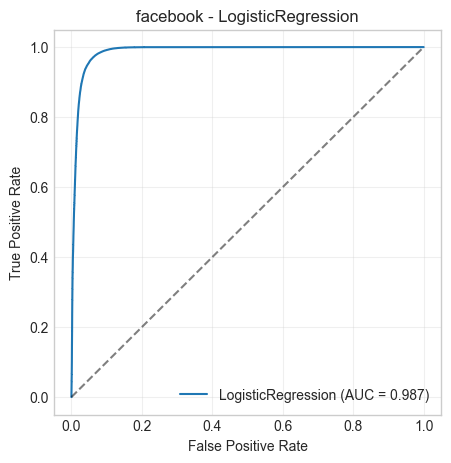


--- RandomForest ---
AUC-ROC (CV): 0.9884
Модель сохранена: c:\ML\graph_analysis_project\models\facebook_RandomForest_linkpred.pkl


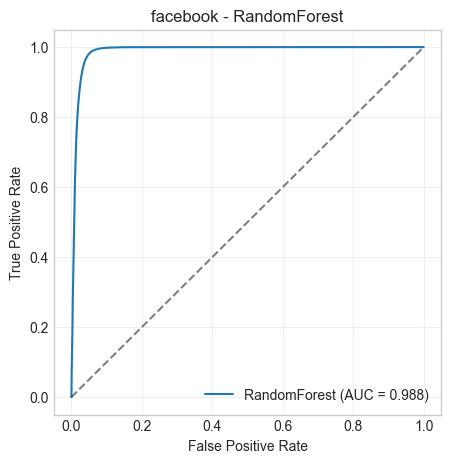


Обработка ARXIV
📂 Загрузка готового графа из arxiv_graph.pkl
Граф: 5242 вершин, 14496 рёбер
📂 Загрузка готовых эмбеддингов из C:\ML\graph_analysis_project\data\processed\embeddings\arxiv_node2vec_d32_p1.0_q1.0_embeddings.pkl
Эмбеддинги: (5242, 32)
Матрица признаков: (28992, 32), баланс: 14496 / 28992

--- LogisticRegression ---
AUC-ROC (CV): 0.9914
Модель сохранена: c:\ML\graph_analysis_project\models\arxiv_LogisticRegression_linkpred.pkl


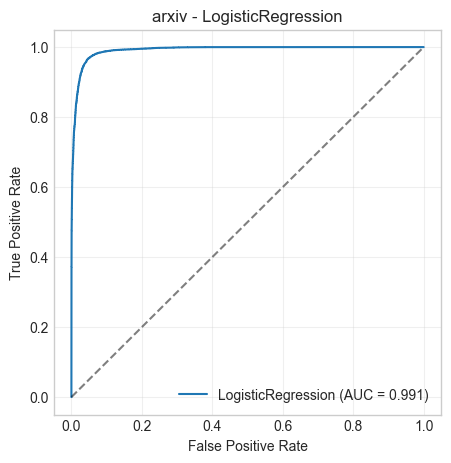


--- RandomForest ---
AUC-ROC (CV): 0.9970
Модель сохранена: c:\ML\graph_analysis_project\models\arxiv_RandomForest_linkpred.pkl


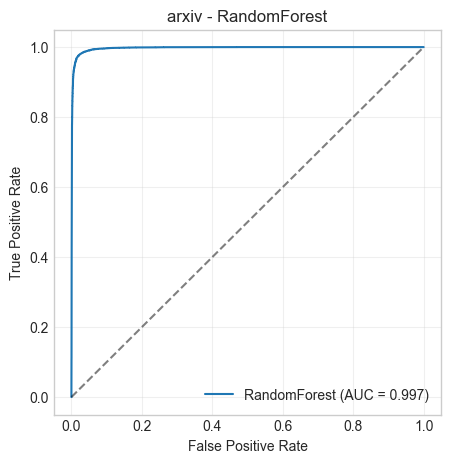


Обработка LASTFM
📂 Загрузка готового графа из lastfm_graph.pkl
Граф: 7624 вершин, 27806 рёбер
📂 Загрузка готовых эмбеддингов из C:\ML\graph_analysis_project\data\processed\embeddings\lastfm_node2vec_d32_p1.0_q1.0_embeddings.pkl
Эмбеддинги: (7624, 32)
Матрица признаков: (55612, 32), баланс: 27806 / 55612

--- LogisticRegression ---
AUC-ROC (CV): 0.9823
Модель сохранена: c:\ML\graph_analysis_project\models\lastfm_LogisticRegression_linkpred.pkl


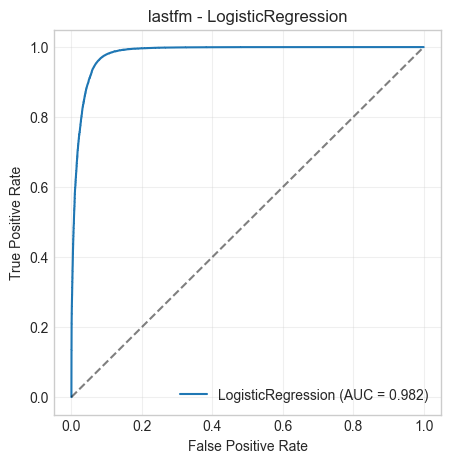


--- RandomForest ---
AUC-ROC (CV): 0.9890
Модель сохранена: c:\ML\graph_analysis_project\models\lastfm_RandomForest_linkpred.pkl


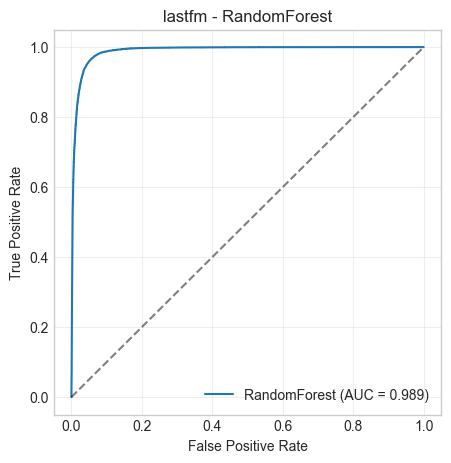


Обработка TWITCH_RU
📂 Загрузка готового графа из twitch_ru_graph.pkl
Граф: 4385 вершин, 37304 рёбер
📂 Загрузка готовых эмбеддингов из C:\ML\graph_analysis_project\data\processed\embeddings\twitch_ru_node2vec_d32_p1.0_q1.0_embeddings.pkl
Эмбеддинги: (4385, 32)
Матрица признаков: (74608, 32), баланс: 37304 / 74608

--- LogisticRegression ---
AUC-ROC (CV): 0.8594
Модель сохранена: c:\ML\graph_analysis_project\models\twitch_ru_LogisticRegression_linkpred.pkl


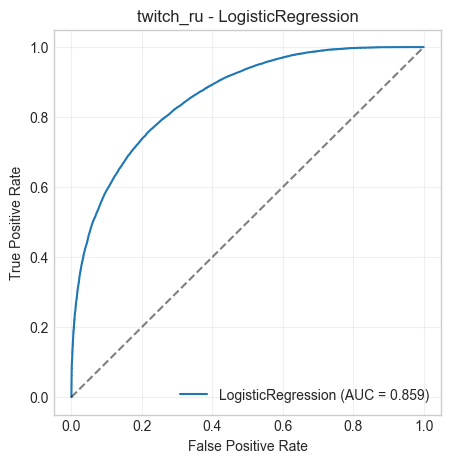


--- RandomForest ---
AUC-ROC (CV): 0.8976
Модель сохранена: c:\ML\graph_analysis_project\models\twitch_ru_RandomForest_linkpred.pkl


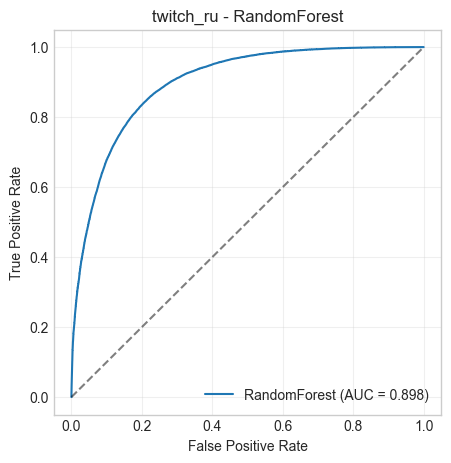

In [4]:
for name in tqdm(DATASETS, desc="Датасеты"):
    print(f"\n{'='*50}")
    print(f"Обработка {name.upper()}")
    print('='*50)
    
    # 1. Загрузка графа
    G = get_graph(name)
    print(f"Граф: {G.number_of_nodes()} вершин, {G.number_of_edges()} рёбер")
    
    # 2. Получение эмбеддингов
    emb_dict, emb_matrix, _ = get_embeddings(
        G, 
        graph_name=name, 
        **EMBEDDING_PARAMS
    )
    print(f"Эмбеддинги: {emb_matrix.shape}")
    
    # 3. Подготовка данных
    X, y = prepare_link_prediction_data(G, emb_matrix)
    print(f"Матрица признаков: {X.shape}, баланс: {y.sum():.0f} / {len(y)}")
    
    # 4. Кросс-валидация и обучение моделей
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    }
    
    for model_name, model in models.items():
        print(f"\n--- {model_name} ---")
        
        # Кросс-валидация для оценки
        y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
        auc = roc_auc_score(y, y_proba)
        print(f"AUC-ROC (CV): {auc:.4f}")
        
        # Обучаем на всех данных и сохраняем
        model.fit(X, y)
        model_path = MODELS_DIR / f"{name}_{model_name}_linkpred.pkl"
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Модель сохранена: {model_path}")
        
        # Сохраняем результат в сводку
        RESULTS.append({
            'dataset': name,
            'model': model_name,
            'auc': auc,
            'nodes': G.number_of_nodes(),
            'edges': G.number_of_edges(),
            'emb_dim': EMBEDDING_PARAMS['dimensions']
        })
        
        # ROC-кривая для визуализации
        fpr, tpr, _ = roc_curve(y, y_proba)
        plt.figure(figsize=(5, 5))
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - {model_name}')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.savefig(PROJECT_ROOT / 'figures' / f'roc_{name}_{model_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

In [5]:
df_results = pd.DataFrame(RESULTS)
df_results = df_results[['dataset', 'model', 'nodes', 'edges', 'emb_dim', 'auc']]
df_results['auc'] = df_results['auc'].round(4)
print("Сводная таблица результатов Link Prediction:")
display(df_results)

# Сохраним таблицу
df_results.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'link_prediction_results.csv', index=False)

Сводная таблица результатов Link Prediction:


,dataset,model,nodes,edges,emb_dim,auc
0,facebook,LogisticRegression,4039,88234,32,0.9872
1,facebook,RandomForest,4039,88234,32,0.9884
2,arxiv,LogisticRegression,5242,14496,32,0.9914
3,arxiv,RandomForest,5242,14496,32,0.9970
4,lastfm,LogisticRegression,7624,27806,32,0.9823
5,lastfm,RandomForest,7624,27806,32,0.9890
6,twitch_ru,LogisticRegression,4385,37304,32,0.8594
7,twitch_ru,RandomForest,4385,37304,32,0.8976


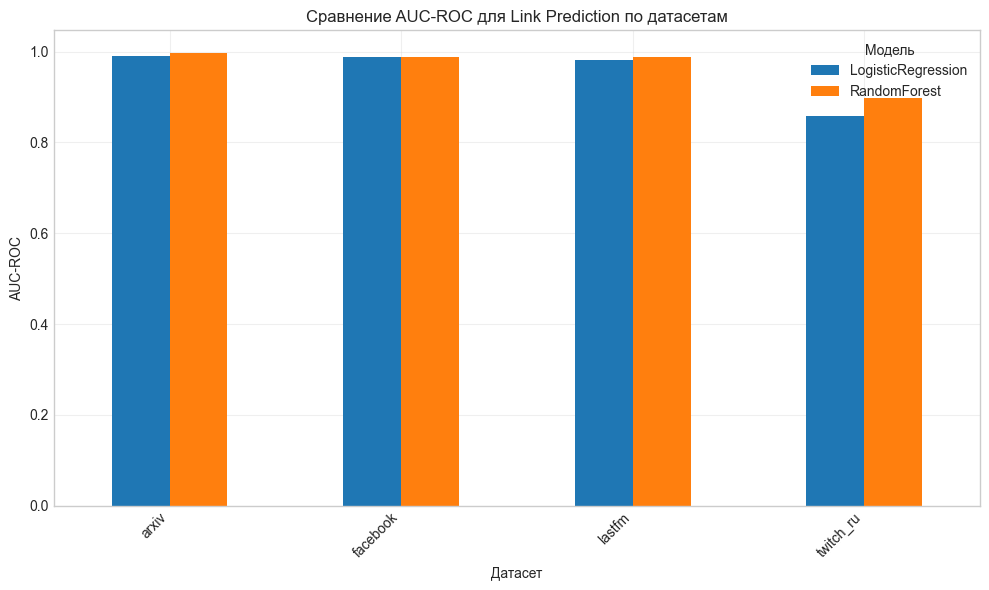

In [6]:
plt.figure(figsize=(10, 6))
pivot = df_results.pivot(index='dataset', columns='model', values='auc')
pivot.plot(kind='bar', ax=plt.gca())
plt.title('Сравнение AUC-ROC для Link Prediction по датасетам')
plt.xlabel('Датасет')
plt.ylabel('AUC-ROC')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Модель')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'link_prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()